<a href="https://colab.research.google.com/github/aaddycool/Parrondo-Paradox-based-Cryptographic-protocol/blob/main/CryptoProtocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit_aer

In [ ]:
!pip install qiskit[visualization]

/usr/local/lib/python3.12/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


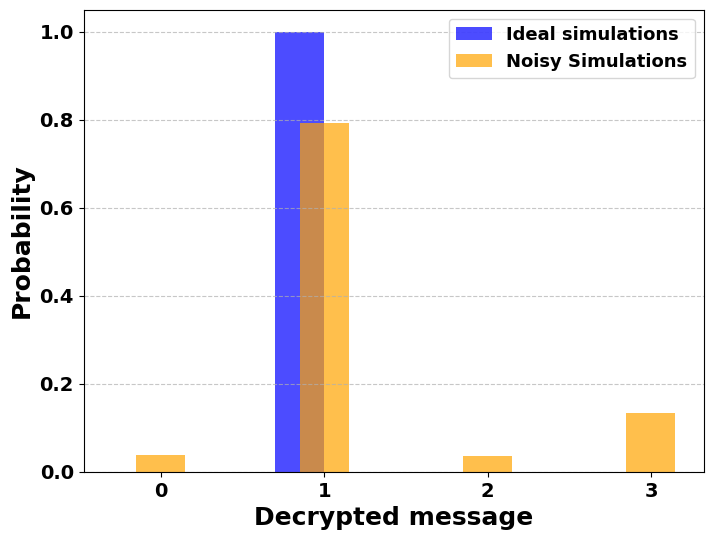

In [ ]:
!pip install qiskit qiskit-aer
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFTGate, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.append(QFTGate(2), [0, 1])
qc.swap(0,1)
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)
qc.swap(0,1)
qc.append(QFTGate(2).inverse(), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

plt.show()

Ideal message probabilities: {0: 0.49161, 1: 0.01078, 2: 0.48682000000000003, 3: 0.010790000000000001}
Noisy message probabilities: {0: 0.43261, 1: 0.062490000000000004, 2: 0.44006, 3: 0.06484000000000001}
{'011000011': 339, '111000001': 152, '011000000': 33772, '001000010': 33532, '111000000': 8780, '011000001': 509, '111000010': 1323, '101000000': 1391, '101000010': 8627, '101000011': 149, '111000011': 76, '001000011': 515, '011000010': 5200, '001000000': 5218, '001000001': 319, '101000001': 98}
{'100000000': 3, '110000000': 27, '010000010': 35, '111000001': 536, '011000000': 26206, '111000010': 2145, '010000001': 1150, '001000011': 1590, '110000011': 252, '111000011': 374, '001000000': 6414, '011000010': 6631, '110000010': 12, '101000010': 8635, '101000011': 499, '010000011': 890, '111000000': 8469, '110000001': 375, '000000000': 37, '101000000': 2008, '000000011': 1227, '001000001': 1162, '011000011': 1276, '000000010': 102, '100000001': 267, '000000001': 886, '010000000': 97, '011

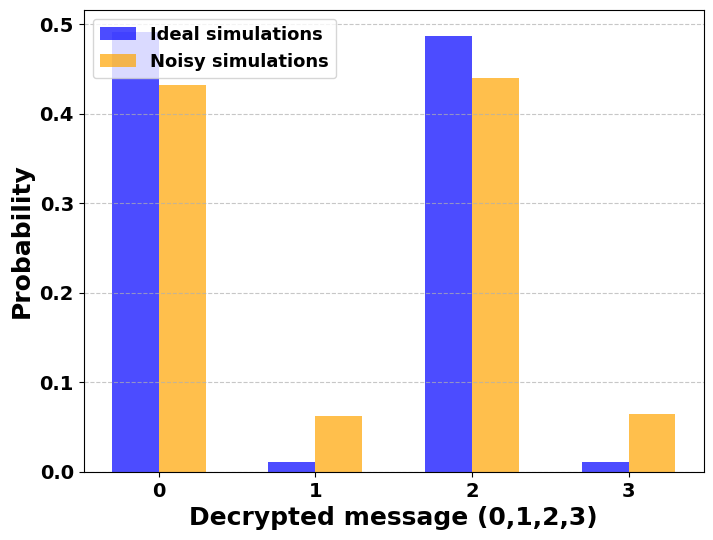

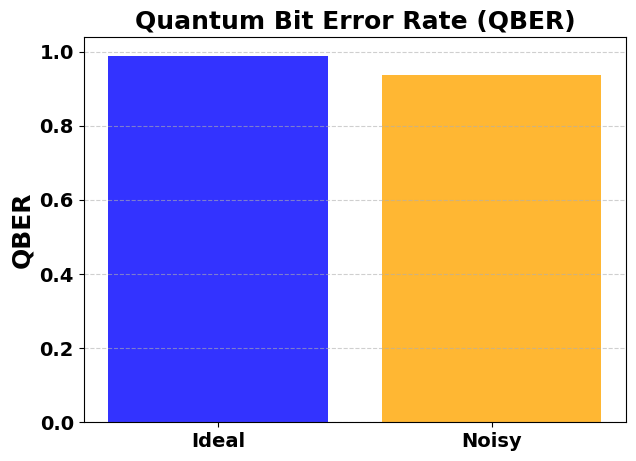

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.quantum_info import random_unitary
from qiskit.visualization import plot_histogram


shots = 100000
p = 0.998489
q = 0.119545

U = random_unitary(2,seed = 123)
A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)],
                          [np.sqrt(1-p), -np.sqrt(p)]]), label='A')

B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)],
                          [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(9,9)

# Alice prepares the public key
qc.append(QFTGate(2), [0, 1])
qc.swap(0,1)

for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()

# Bob receives the key
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)

qc.barrier()

# Bob encodes the message
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()

qc.h(3)
qc.h(4)
#qc.h(5)
qc.measure([3,4,5],[6,7,8])

# Eve intercepts (qubits 6,7,8)
#qc.reset([6,7,8])

# Recreate Bob’s measured classical bits into Eve’s qubits
with qc.if_test((6, 1)):
    qc.x(6)

with qc.if_test((7, 1)):
    qc.x(7)

with qc.if_test((8, 1)):
    qc.x(8)

# Eve applies Bob’s encoding operations on HER qubits
qc.unitary(U,6)
qc.unitary(U,7)


# Alice receives back
qc.swap(6, 0)
qc.swap(7, 1)
qc.swap(8, 2)

qc.barrier()

# Decryption sequence
for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)
qc.swap(0,1)
qc.append(QFTGate(2), [0, 1]).inverse()

qc.barrier()
qc.measure([0,1],[0,1])

# ---------------- NOISE MODEL ---------------------- #
prob_noise = 0.03
prob_noise_1 = 0.03

error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])

basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# ---------------- RUN ---------------------- #
result = simulator.run(qc_t, shots=shots).result()
counts = result.get_counts()

result_noisy = simulator.run(
    qc_t,
    shots=shots,
    noise_model=noise_model,
    basis_gates=basis_gates
).result()

counts_noisy = result_noisy.get_counts()


# ==========================================================
# CORRECTED PROBABILITY MAPPING FOR 4 MESSAGES
# ==========================================================
# Alice's final measurement is stored in classical bits [0,1]
# So from bitstring "... c1 c0" → message = int("c1c0",2)

def extract_msg_prob(counts, shots):
    probs = {0:0, 1:0, 2:0, 3:0}
    for bitstring, cnt in counts.items():
        msg_bits = bitstring[-2:]      # last two classical bits c1 c0
        msg_int  = int(msg_bits, 2)     # value 0..3
        probs[msg_int] += cnt/shots
    return probs

prob = extract_msg_prob(counts, shots)
prob_noisy = extract_msg_prob(counts_noisy, shots)

print("Ideal message probabilities:", prob)
print("Noisy message probabilities:", prob_noisy)
print(counts)
print(counts_noisy)

# ==========================================================
# PLOTTING
# ==========================================================
positions = [0, 1, 2, 3]

prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]

fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3

ax.bar([p - width/2 for p in positions], prob_values,
       width=width, alpha=0.7, color="blue", label="Ideal simulations")

ax.bar([p + width/2 for p in positions], prob_noisy_values,
       width=width, alpha=0.7, color="orange", label="Noisy simulations")

ax.set_xlabel("Decrypted message (0,1,2,3)", fontsize=18, fontweight='bold')
ax.set_ylabel("Probability", fontsize=18, fontweight='bold')

ax.set_xticks(positions)
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)

ax.legend(prop={'weight':'bold','size':13})
ax.grid(axis='y', linestyle='--', alpha=0.7)


# ==========================================================
# QBER COMPUTATION
# ==========================================================
expected_msg = 1   # because your encoding is for message m = 1

QBER_ideal = 1 - prob[expected_msg]
QBER_noisy = 1 - prob_noisy[expected_msg]

print("\nQBER (ideal):", QBER_ideal)
print("QBER (noisy):", QBER_noisy)

# ==========================================================
# PLOT QBER
# ==========================================================
plt.figure(figsize=(7,5))
plt.bar(["Ideal", "Noisy"],
        [QBER_ideal, QBER_noisy],
        color=["blue","orange"],
        alpha=0.8)

plt.ylabel("QBER", fontsize=18, fontweight='bold')
plt.title("Quantum Bit Error Rate (QBER)", fontsize=18, fontweight='bold')

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
